# Unsupervised Feature Selection Using Sparse Manifold Auto-Encoder (SMFAE)

## Dataset: Colon Microarray ($d=2000$ features, $n=62$ samples, 2 classes)

**Paper Reference**: Moslemi, A., & Jamshidi, M. (2025). *Unsupervised feature selection using sparse manifold learning: Auto-encoder approach*. Information Processing and Management, 62(1), 103923.

### Module 1: Environment Setup & Library Imports

Import standard numerical, optimization, clustering, and preprocessing tools, and fix the random seed for reproducibility.

In [14]:
import numpy as np
import pandas as pd
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist
from sklearn.cluster import KMeans
from sklearn.metrics import normalized_mutual_info_score
from sklearn.preprocessing import StandardScaler

# Random seed for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("Module 1 initialized: Environment ready.")


Module 1 initialized: Environment ready.


## Module 2: Data Loading & Preprocessing

Load the Colon CSV dataset, separate feature columns from the class label, apply Z-score
standardization across samples, and transpose to the paper's matrix notation
$X \in \mathbb{R}^{d \times n}$ ($d=2000$ features, $n=62$ samples).

In [18]:
def load_and_preprocess_colon(csv_path="../data/preprocessed/colon.csv"):
    '''Loads the Colon CSV, applies Z-score normalization, and transposes to X in R^(d x n).'''
    df = pd.read_csv(csv_path)

    # Identify label column
    if "target" in df.columns:
        label_col = "target"
    elif "label" in df.columns:
        label_col = "label"
    else:
        label_col = df.columns[-1]

    y_true = df[label_col].to_numpy()
    X_df = df.drop(columns=[label_col])
    X_raw = X_df.to_numpy(dtype=np.float64)

    # 1. Z-score standardization across samples
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_raw)

    # 2. Transpose to paper notation: X in R^(d x n)
    X = X_scaled.T

    return X, y_true


# Execute loading
CSV_PATH = "../data/preprocessed/colon.csv"  # update path if needed
X, y_true = load_and_preprocess_colon(CSV_PATH)

d_features, n_samples = X.shape
n_classes = len(np.unique(y_true))

print(
    f"Colon Dataset Loaded: d = {d_features} features, n = {n_samples}"
    f" samples, classes = {n_classes}"
)
assert X.shape == (2000, 62), f"Expected X shape (2000, 62), but got {X.shape}"


Colon Dataset Loaded: d = 2000 features, n = 62 samples, classes = 2


## Module 3: Graph Laplacian Matrix ($L_X$) Construction

Build a $k$-nearest-neighbor ($k=5$) graph using Gaussian kernel similarity
$A_{ij} = \exp(-\|x_i - x_j\|^2 / 2\sigma^2)$. Compute the degree matrix $D$ and construct the
unnormalized Laplacian $L_X = D - A \in \mathbb{R}^{62 \times 62}$.

In [19]:
# ============================================================
# Cell 3: Module 3 — Graph Laplacian & Operator Scale Construction
# ============================================================

import numpy as np
from scipy.spatial.distance import cdist


def build_graph_laplacian(X, k=5):
    """
    Construct k-NN similarity matrix A,
    Laplacian L_X = D - A,
    and memory-safe operator scale C_op.
    """

    d, n = X.shape

    X_samples = X.T  # (n, d)

    # --------------------------------------------------------
    # Pairwise squared Euclidean distances
    # --------------------------------------------------------

    dist_sq = cdist(
        X_samples,
        X_samples,
        metric="sqeuclidean"
    )

    nonzero_dist = dist_sq[dist_sq > 0]

    sigma = (
        np.sqrt(np.median(nonzero_dist))
        if len(nonzero_dist) > 0
        else 1.0
    )

    # --------------------------------------------------------
    # Symmetric k-NN adjacency matrix
    # --------------------------------------------------------

    A = np.zeros(
        (n, n),
        dtype=np.float64
    )

    for i in range(n):

        knn_indices = np.argsort(
            dist_sq[i]
        )[1:k + 1]

        for j in knn_indices:

            sim = np.exp(
                -dist_sq[i, j]
                / (2.0 * (sigma ** 2))
            )

            A[i, j] = sim
            A[j, i] = sim

    np.fill_diagonal(A, 0.0)

    # --------------------------------------------------------
    # Degree matrix and Graph Laplacian
    # --------------------------------------------------------

    D = np.diag(
        np.sum(A, axis=1)
    )

    L_X = D - A

    # --------------------------------------------------------
    # Memory-safe operator scale
    #
    # C_op = ||X L_X X^T||_F
    #
    # Using:
    #
    # ||X L X^T||_F^2
    # = Tr((X^T X)L(X^T X)L)
    #
    # Only 62 x 62 matrices are created.
    # --------------------------------------------------------

    XTX = np.dot(
        X.T,
        X
    )  # (62, 62)

    M62 = np.dot(
        np.dot(XTX, L_X),
        np.dot(XTX, L_X)
    )  # (62, 62)

    C_op = np.sqrt(
        np.trace(M62)
    )

    return L_X, A, D, C_op


# ------------------------------------------------------------
# Build graph and operator scale
# ------------------------------------------------------------

L_X, A_mat, D_mat, C_op = build_graph_laplacian(
    X,
    k=5
)

print(
    f"Graph Laplacian L_X constructed: shape {L_X.shape}"
)

print(
    f"Input manifold operator scale C_op = {C_op:.4f}"
)

Graph Laplacian L_X constructed: shape (62, 62)
Input manifold operator scale C_op = 55735.8727


## Module 4: Sparse Manifold Auto-Encoder Optimization Engine

Implement forward propagation with a Sigmoid encoder $Z = \sigma(W^{(1)T}X)$ and a **Linear**
decoder $\hat{X} = W^{(2)T}Z$ (chosen so the decoder can reproduce Z-scored real-valued data),
backpropagation gradients for $W^{(1)}$ and $W^{(2)}$, the $l_{2,1}$ sparsity matrix $Q$, the
multiplicative update for the auxiliary matrix $H$, and the master training loop
(`train_smfae`).

In [20]:
# ============================================================
# Cell 4: Module 4 — Normalized & Memory-Safe SMFAE Engine
# ============================================================

import numpy as np


# ------------------------------------------------------------
# Activation Functions
# ------------------------------------------------------------

def sigmoid(x):
    return 1.0 / (
        1.0 + np.exp(-np.clip(x, -50, 50))
    )


def sigmoid_deriv(x):
    s = sigmoid(x)
    return s * (1.0 - s)


# ------------------------------------------------------------
# Gradient Computation
# ------------------------------------------------------------

def compute_gradients(
    W1,
    W2,
    X,
    L_X,
    H,
    C_op,
    alpha=0.01,
    beta=0.0001,
    gamma=1.0,
    omega=0.001,
    return_components=False
):
    """
    Computes analytical gradients for SMFAE.

    The input-manifold gradient is normalized using C_op:

        C_op = ||X L_X X^T||_F

    The large (d x d) matrix X L_X X^T is never explicitly
    constructed. Instead, matrix associativity is used:

        X @ (L_X @ (X.T @ W1))
    """

    d, n = X.shape
    k = W1.shape[1]

    # ========================================================
    # 1. Forward Pass
    # ========================================================

    A_act = np.dot(
        W1.T,
        X
    )                                  # (k, n)

    Z = sigmoid(
        A_act
    )                                  # (k, n)

    X_hat = np.dot(
        W2.T,
        Z
    )                                  # (d, n)

    # ========================================================
    # 2. Backpropagation Error Terms
    # ========================================================

    delta_o = X_hat - X               # (d, n)

    delta_h = (
        np.dot(W2, delta_o)
        * sigmoid_deriv(A_act)
    )                                  # (k, n)

    # ========================================================
    # 3. Reconstruction Gradient
    # ========================================================

    grad_W1_recon = (
        np.dot(X, delta_h.T) / n
    )                                  # (d, k)

    grad_W2_recon = (
        np.dot(delta_o, Z.T) / n
    ).T                                # (k, d)

    # ========================================================
    # 4. L2,1 Sparsity Gradient
    # ========================================================

    eps = 1e-8

    row_norms = np.sqrt(
        np.sum(W1 ** 2, axis=1, keepdims=True)
        + eps
    )                                  # (d, 1)

    grad_W1_sparse = (
        alpha * (W1 / row_norms)
    )                                  # (d, k)

    # ========================================================
    # 5. Weight Decay Gradient
    # ========================================================

    grad_W1_decay = beta * W1
    grad_W2_decay = beta * W2

    # ========================================================
    # 6. Normalized Input Manifold Gradient
    #
    # Original:
    #
    # gamma * (X L_X X^T) W1
    #
    # Memory-safe:
    #
    # X @ (L_X @ (X.T @ W1))
    #
    # Normalized:
    #
    # (gamma / C_op) *
    # X @ (L_X @ (X.T @ W1))
    # ========================================================

    XT_W1 = np.dot(
        X.T,
        W1
    )                                  # (n, k)

    LX_XT_W1 = np.dot(
        L_X,
        XT_W1
    )                                  # (n, k)

    grad_W1_input = (
        gamma
        * np.dot(X, LX_XT_W1)
    )                                  # (d, k)

    # ========================================================
    # 7. Output Manifold Gradient
    # ========================================================

    HH_T = np.dot(
        H,
        H.T
    )                                  # (n, n)

    W2_W2T = np.dot(
        W2,
        W2.T
    )                                  # (k, k)

    ZT_W2_W2T = np.dot(
        Z.T,
        W2_W2T
    )                                  # (n, k)

    M = np.dot(
        HH_T,
        ZT_W2_W2T
    )                                  # (n, k)

    delta_Z_output = (
        M.T
        * sigmoid_deriv(A_act)
    )                                  # (k, n)

    grad_W1_output = (
        (omega / n)
        * np.dot(
            X,
            delta_Z_output.T
        )
    )                                  # (d, k)

    grad_W2_output = (
        (omega / n)
        * np.dot(
            np.dot(
                np.dot(
                    Z,
                    HH_T
                ),
                Z.T
            ),
            W2
        )
    )                                  # (k, d)

    # ========================================================
    # 8. Total Analytical Gradients
    # ========================================================

    grad_W1 = (
        grad_W1_recon
        + grad_W1_sparse
        + grad_W1_decay
        + grad_W1_input
        + grad_W1_output
    )

    grad_W2 = (
        grad_W2_recon
        + grad_W2_decay
        + grad_W2_output
    )

    # ========================================================
    # 9. Optional Gradient Diagnostics
    # ========================================================

    if return_components:

        components = {
            "norm_W1_recon":
                np.linalg.norm(
                    grad_W1_recon
                ),

            "norm_W1_sparse":
                np.linalg.norm(
                    grad_W1_sparse
                ),

            "norm_W1_decay":
                np.linalg.norm(
                    grad_W1_decay
                ),

            "norm_W1_input":
                np.linalg.norm(
                    grad_W1_input
                ),

            "norm_W1_output":
                np.linalg.norm(
                    grad_W1_output
                ),

            "norm_W1_total":
                np.linalg.norm(
                    grad_W1
                ),

            "norm_W2_total":
                np.linalg.norm(
                    grad_W2
                )
        }

        return (
            grad_W1,
            grad_W2,
            components
        )

    return grad_W1, grad_W2


# ------------------------------------------------------------
# Auxiliary H Update
# ------------------------------------------------------------

def update_auxiliary_H(
    H,
    A_mat,
    D_mat,
    eps=1e-8
):
    """
    Multiplicative update for H >= 0.
    """

    num = 2.0 * np.dot(
        A_mat,
        H
    )

    den = (
        2.0 * np.dot(
            D_mat,
            H
        )
        + 4.0 * np.dot(
            np.dot(H, H.T),
            H
        )
        + eps
    )

    H_updated = H * (
        num / den
    )

    return np.maximum(
        H_updated,
        eps
    )


# ------------------------------------------------------------
# SMFAE Training Engine
# ------------------------------------------------------------

def train_smfae(
    X,
    L_X,
    A_mat,
    D_mat,
    C_op,
    hidden_dim=4,
    alpha=0.01,
    beta=0.0001,
    gamma=1.0,
    omega=0.001,
    epochs=250,
    rho1=0.01,
    rho2=0.005,
    seed=42
):
    """
    Master training engine for normalized SMFAE.
    """

    d, n = X.shape
    k = hidden_dim

    rng = np.random.default_rng(
        seed
    )

    # ========================================================
    # Weight Initialization
    # ========================================================

    limit_W1 = np.sqrt(
        6.0 / (d + k)
    )

    limit_W2 = np.sqrt(
        6.0 / (k + d)
    )

    W1 = rng.uniform(
        -limit_W1,
        limit_W1,
        size=(d, k)
    )

    W2 = rng.uniform(
        -limit_W2,
        limit_W2,
        size=(k, d)
    )

    H = (
        np.abs(
            rng.normal(
                0.0,
                0.01,
                size=(n, n)
            )
        )
        + 1e-3
    )

    # ========================================================
    # Optimization Loop
    # ========================================================

    for epoch in range(
        1,
        epochs + 1
    ):

        grad_W1, grad_W2 = compute_gradients(
            W1,
            W2,
            X,
            L_X,
            H,
            C_op,
            alpha,
            beta,
            gamma,
            omega
        )

        # Gradient clipping to prevent gradient explosion
        grad_W1 = np.clip(grad_W1, -10.0, 10.0)
        grad_W2 = np.clip(grad_W2, -10.0, 10.0)

        W1 -= (
            rho1 * grad_W1
        )

        W2 -= (
            rho2 * grad_W2
        )

        H = update_auxiliary_H(
            H,
            A_mat,
            D_mat
        )

        # ----------------------------------------------------
        # Numerical Safety
        # ----------------------------------------------------

        W1 = np.nan_to_num(
            W1,
            nan=0.0,
            posinf=1e6,
            neginf=-1e6
        )

        W2 = np.nan_to_num(
            W2,
            nan=0.0,
            posinf=1e6,
            neginf=-1e6
        )

    return W1, W2, H


print(
    "Module 4 compiled: "
    "Normalized SMFAE optimization engine ready."
)

Module 4 compiled: Normalized SMFAE optimization engine ready.


## Module 5: Model Training & Feature Importance Ranking

Train the auto-encoder on the Colon dataset with hidden layer size
$k = \operatorname{round}(\sqrt{62}/2) = 4$. Compute feature importance scores
$s_i = \|w_i^{(1)}\|_2$ from the encoder weight matrix $W^{(1)}$ and rank features in
descending order.

In [21]:
# ============================================================
# Cell 5: Module 5 — Training Execution & Feature Ranking
# Normalized SMFAE
# ============================================================

HIDDEN_DIM = int(
    np.round(np.sqrt(n_samples) / 2.0)
)

# For Colon: n = 62 -> hidden dimension = 4
print(f"Hidden dimension: {HIDDEN_DIM}")


def train_and_rank(
    X,
    L_X,
    A_mat,
    D_mat,
    C_op,
    alpha=0.01,
    beta=0.0001,
    gamma=1.0,
    omega=0.001,
    rho1=0.01,
    rho2=0.005,
    epochs=500
):
    """
    Train normalized SMFAE and rank features according
    to the descending L2 norm of rows of W1.
    """

    W1, W2, H = train_smfae(
        X=X,
        L_X=L_X,
        A_mat=A_mat,
        D_mat=D_mat,
        C_op=C_op,
        hidden_dim=HIDDEN_DIM,
        alpha=alpha,
        beta=beta,
        gamma=gamma,
        omega=omega,
        epochs=epochs,
        rho1=rho1,
        rho2=rho2,
        seed=RANDOM_SEED
    )

    # --------------------------------------------------------
    # Feature importance = row-wise L2 norm of W1
    # --------------------------------------------------------

    feature_scores = np.linalg.norm(
        W1,
        axis=1
    )

    # Highest-scoring features first
    ranked_indices = np.argsort(
        feature_scores
    )[::-1]

    return ranked_indices


print(
    "Module 5 compiled: "
    "Normalized feature ranking engine ready."
)

Hidden dimension: 4
Module 5 compiled: Normalized feature ranking engine ready.


## Module 6: Benchmark Evaluation (ACC & NMI)

Evaluate selected feature subsets $r \in \{50, 100, 150, 200, 250, 300\}$. For each subset,
standardize the features with `StandardScaler` and evaluate K-Means ($K=2$, 30 repetitions)
using Clustering Accuracy (ACC, via the Hungarian algorithm) and Normalized Mutual Information
(NMI).

In [22]:
# ============================================================
# Cell 6: Module 6 — Final Benchmark Evaluation
# k = 5 experiment with fixed best configuration
# ============================================================

import pandas as pd

from scipy.optimize import linear_sum_assignment
from sklearn.cluster import KMeans
from sklearn.metrics import normalized_mutual_info_score
from sklearn.preprocessing import StandardScaler


# ============================================================
# 1. Clustering Accuracy
# ============================================================

def calculate_acc(y_true, y_pred):

    y_true = np.asarray(
        y_true,
        dtype=np.int64
    )

    y_pred = np.asarray(
        y_pred,
        dtype=np.int64
    )

    _, y_true = np.unique(
        y_true,
        return_inverse=True
    )

    _, y_pred = np.unique(
        y_pred,
        return_inverse=True
    )

    D = max(
        y_pred.max(),
        y_true.max()
    ) + 1

    w = np.zeros(
        (D, D),
        dtype=np.int64
    )

    for i in range(
        y_pred.size
    ):
        w[
            y_pred[i],
            y_true[i]
        ] += 1

    row_ind, col_ind = linear_sum_assignment(
        w.max() - w
    )

    return (
        w[row_ind, col_ind].sum()
        / y_pred.size
    )


# ============================================================
# 2. Fixed Best Configuration
# ============================================================

alpha_val = 0.0001
beta_val = 0.0001
gamma_val = 0.0005
omega_val = 0.01

epochs = 500

feature_counts = [
    50,
    100,
    150,
    200,
    250,
    300
]


print("=== Final k=3 Experiment ===")

print(
    f"alpha={alpha_val}, "
    f"beta={beta_val}, "
    f"gamma={gamma_val}, "
    f"omega={omega_val}"
)

print(
    f"epochs={epochs}, KMeans n_init=50\n"
)


# ============================================================
# 3. Train SMFAE and Rank Features
# ============================================================

ranked_indices = train_and_rank(
    X=X,
    L_X=L_X,
    A_mat=A_mat,
    D_mat=D_mat,
    C_op=C_op,
    alpha=alpha_val,
    beta=beta_val,
    gamma=gamma_val,
    omega=omega_val,
    rho1=0.01,
    rho2=0.005,
    epochs=epochs
)


# ============================================================
# 4. Benchmark Evaluation
# ============================================================

subset_evals = []


for r in feature_counts:

    selected_indices = (
        ranked_indices[:r]
    )

    # X is (features, samples)
    # KMeans expects (samples, features)

    X_selected = (
        X[selected_indices, :].T
    )


    # Standardize selected features

    X_selected_scaled = (
        StandardScaler()
        .fit_transform(
            X_selected
        )
    )


    acc_list = []
    nmi_list = []


    # --------------------------------------------------------
    # 30 KMeans repetitions
    # --------------------------------------------------------

    for seed in range(30):

        kmeans = KMeans(
            n_clusters=n_classes,
            n_init=50,
            random_state=seed
        )

        y_pred = (
            kmeans.fit_predict(
                X_selected_scaled
            )
        )


        acc_list.append(
            calculate_acc(
                y_true,
                y_pred
            )
        )


        nmi_list.append(
            normalized_mutual_info_score(
                y_true,
                y_pred
            )
        )


    # --------------------------------------------------------
    # Store results
    # --------------------------------------------------------

    subset_evals.append({

        "Selected Features (r)": r,

        "ACC_mean":
            np.mean(acc_list) * 100,

        "ACC_std":
            np.std(acc_list) * 100,

        "NMI_mean":
            np.mean(nmi_list) * 100,

        "NMI_std":
            np.std(nmi_list) * 100,

        "ACC (%)":
            f"{np.mean(acc_list) * 100:.2f} ± "
            f"{np.std(acc_list) * 100:.2f}",

        "NMI (%)":
            f"{np.mean(nmi_list) * 100:.2f} ± "
            f"{np.std(nmi_list) * 100:.2f}"
    })


# ============================================================
# 5. Final Results
# ============================================================

results_df = pd.DataFrame(
    subset_evals
)


best_mean_nmi = (
    results_df["NMI_mean"].mean()
)


best_row = results_df.loc[
    results_df["NMI_mean"].idxmax()
]


print(
    "\n=== Final k=3 Experiment Complete ==="
)


print(
    f"\nMean NMI Across Feature Counts: "
    f"{best_mean_nmi:.2f}%"
)


print(
    f"\nBest Feature Count: "
    f"r={int(best_row['Selected Features (r)'])}"
)


print(
    f"Best NMI: "
    f"{best_row['NMI_mean']:.2f}%"
)


print(
    f"Corresponding ACC: "
    f"{best_row['ACC_mean']:.2f}%"
)


print(
    "\n--- Benchmark Table on Colon Dataset ---"
)


print(
    results_df[
        [
            "Selected Features (r)",
            "ACC (%)",
            "NMI (%)"
        ]
    ].to_string(
        index=False
    )
)

=== Final k=3 Experiment ===
alpha=0.0001, beta=0.0001, gamma=0.0005, omega=0.01
epochs=500, KMeans n_init=50



Cloning into 'smfs-autoencoder'...



=== Final k=3 Experiment Complete ===

Mean NMI Across Feature Counts: 1.00%

Best Feature Count: r=100
Best NMI: 2.02%
Corresponding ACC: 59.68%

--- Benchmark Table on Colon Dataset ---
 Selected Features (r)      ACC (%)     NMI (%)
                    50 56.45 ± 0.00 0.99 ± 0.00
                   100 59.68 ± 0.00 2.02 ± 0.00
                   150 56.51 ± 0.29 0.72 ± 0.14
                   200 56.45 ± 0.00 0.99 ± 0.00
                   250 54.84 ± 0.00 0.62 ± 0.00
                   300 54.84 ± 0.00 0.62 ± 0.00


In [23]:
# ============================================================
# Cell 7: Standalone Memory-Safe Gradient Component Diagnostic
# ============================================================

import numpy as np

d, n = X.shape
k = 4  # hidden dimension for Colon dataset (n=62)

rng = np.random.default_rng(RANDOM_SEED)

# ------------------------------------------------------------
# Initialize weights at default initialization scale
# ------------------------------------------------------------

limit_W1 = np.sqrt(6.0 / (d + k))
limit_W2 = np.sqrt(6.0 / (k + d))

W1_init = rng.uniform(
    -limit_W1,
    limit_W1,
    size=(d, k)
)

W2_init = rng.uniform(
    -limit_W2,
    limit_W2,
    size=(k, d)
)

H_init = (
    np.abs(
        rng.normal(
            0.0,
            0.01,
            size=(n, n)
        )
    )
    + 1e-3
)

# ------------------------------------------------------------
# Execute single-pass memory-safe gradient diagnostic
# ------------------------------------------------------------

_, _, comp = compute_gradients(
    W1=W1_init,
    W2=W2_init,
    X=X,
    L_X=L_X,
    H=H_init,
    C_op=C_op,
    alpha=0.01,
    beta=0.0001,
    gamma=0.001,
    omega=0.001,
    return_components=True
)

total_norm = comp["norm_W1_total"]

# ------------------------------------------------------------
# Display gradient component norms
# ------------------------------------------------------------

print("=== SMFAE Encoder Gradient Component Diagnostic ===")

print(
    f"1. Reconstruction Gradient  "
    f"(||grad_W1_recon||)  : "
    f"{comp['norm_W1_recon']:10.6f}  "
    f"({comp['norm_W1_recon']/total_norm*100:5.2f}%)"
)

print(
    f"2. Sparsity Gradient        "
    f"(||grad_W1_sparse||) : "
    f"{comp['norm_W1_sparse']:10.6f}  "
    f"({comp['norm_W1_sparse']/total_norm*100:5.2f}%)"
)

print(
    f"3. Weight Decay Gradient    "
    f"(||grad_W1_decay||)  : "
    f"{comp['norm_W1_decay']:10.6f}  "
    f"({comp['norm_W1_decay']/total_norm*100:5.2f}%)"
)

print(
    f"4. Input Manifold Gradient  "
    f"(||grad_W1_input||)  : "
    f"{comp['norm_W1_input']:10.6f}  "
    f"({comp['norm_W1_input']/total_norm*100:5.2f}%)"
)

print(
    f"5. Output Manifold Gradient "
    f"(||grad_W1_output||) : "
    f"{comp['norm_W1_output']:10.6f}  "
    f"({comp['norm_W1_output']/total_norm*100:5.2f}%)"
)

print("-" * 55)

print(
    f"Total Encoder Gradient      "
    f"(||grad_W1_total||)  : "
    f"{comp['norm_W1_total']:10.6f}"
)

print(
    f"Total Decoder Gradient      "
    f"(||grad_W2_total||)  : "
    f"{comp['norm_W2_total']:10.6f}"
)

=== SMFAE Encoder Gradient Component Diagnostic ===
1. Reconstruction Gradient  (||grad_W1_recon||)  :  10.907188  (85.66%)
2. Sparsity Gradient        (||grad_W1_sparse||) :   0.447213  ( 3.51%)
3. Weight Decay Gradient    (||grad_W1_decay||)  :   0.000282  ( 0.00%)
4. Input Manifold Gradient  (||grad_W1_input||)  :   3.668308  (28.81%)
5. Output Manifold Gradient (||grad_W1_output||) :   0.000310  ( 0.00%)
-------------------------------------------------------
Total Encoder Gradient      (||grad_W1_total||)  :  12.733011
Total Decoder Gradient      (||grad_W2_total||)  :   8.672604


In [24]:
# Cell 7: Isolated Baseline Diagnostic
# Supervised ANOVA vs Variance vs Current SMFAE W1

import numpy as np
import pandas as pd
from scipy.optimize import linear_sum_assignment
from sklearn.cluster import KMeans
from sklearn.feature_selection import f_classif
from sklearn.metrics import normalized_mutual_info_score
from sklearn.preprocessing import StandardScaler


def calculate_acc(y_true, y_pred):
    """Computes clustering accuracy using the Hungarian algorithm."""
    y_true = np.asarray(y_true, dtype=np.int64)
    y_pred = np.asarray(y_pred, dtype=np.int64)

    _, y_true = np.unique(y_true, return_inverse=True)
    _, y_pred = np.unique(y_pred, return_inverse=True)

    D = max(y_pred.max(), y_true.max()) + 1

    w = np.zeros((D, D), dtype=np.int64)

    for i in range(y_pred.size):
        w[y_pred[i], y_true[i]] += 1

    row_ind, col_ind = linear_sum_assignment(w.max() - w)

    return w[row_ind, col_ind].sum() / y_pred.size


# ============================================================
# 1. Feature Rankings to Compare
# ============================================================

# A. Supervised ANOVA F-Score Ranking
# X has shape: (features, samples) = (2000, 62)
# f_classif expects: (samples, features)
f_scores, _ = f_classif(X.T, y_true)

supervised_f_ranking = np.argsort(f_scores)[::-1]


# B. Unsupervised Variance Ranking
var_scores = np.var(X, axis=1)

variance_ranking = np.argsort(var_scores)[::-1]


# C. Current SMFAE W1 Ranking
# Use the optimal configuration obtained in Cell 6
smfae_ranking = train_and_rank(
    X=X,
    L_X=L_X,
    A_mat=A_mat,
    D_mat=D_mat,
    C_op=C_op,
    alpha=0.0001,
    beta=0.0001,
    gamma=50.0,
    omega=0.01,
    rho1=0.01,
    rho2=0.005,
    epochs=250,
)


# ============================================================
# 2. Rankings to Evaluate
# ============================================================

rankings_to_test = {
    '1. Supervised ANOVA F-Score (Upper Bound)': supervised_f_ranking,
    '2. Unsupervised Variance Ranking': variance_ranking,
    '3. Current SMFAE W1 Ranking': smfae_ranking,
}


# Same feature counts used throughout our previous experiments
feature_counts = [50, 100, 150, 200, 250, 300]


# ============================================================
# 3. Evaluate Each Ranking
# ============================================================

diagnostic_summary = []

print('=== Running Feature Selection Baseline Diagnostic ===\n')

for label, ranking in rankings_to_test.items():

    print(f'Evaluating {label}...')

    for r in feature_counts:

        selected_indices = ranking[:r]

        # X: (features, samples)
        # After selection: (r, 62)
        # Transpose for sklearn: (62, r)
        X_selected = X[selected_indices, :].T

        # Same scaling protocol as Cell 6
        X_selected_scaled = StandardScaler().fit_transform(X_selected)

        acc_list = []
        nmi_list = []

        for seed in range(30):

            kmeans = KMeans(
                n_clusters=n_classes,
                n_init=10,
                random_state=seed
            )

            y_pred = kmeans.fit_predict(X_selected_scaled)

            acc_list.append(
                calculate_acc(y_true, y_pred)
            )

            nmi_list.append(
                normalized_mutual_info_score(y_true, y_pred)
            )

        diagnostic_summary.append({
            'Method': label,
            'r': r,
            'ACC (%)':
                f'{np.mean(acc_list)*100:.2f} ± '
                f'{np.std(acc_list)*100:.2f}',
            'NMI (%)':
                f'{np.mean(nmi_list)*100:.2f} ± '
                f'{np.std(nmi_list)*100:.2f}',
        })


# ============================================================
# 4. Display Diagnostic Results
# ============================================================

diag_df = pd.DataFrame(diagnostic_summary)

print('\n=== Diagnostic Summary Tables ===')


pivoted_nmi = diag_df.pivot(
    index='Method',
    columns='r',
    values='NMI (%)'
)

print('\n--- NMI (%) Across Feature Counts r ---')
print(pivoted_nmi.to_string())


pivoted_acc = diag_df.pivot(
    index='Method',
    columns='r',
    values='ACC (%)'
)

print('\n--- ACC (%) Across Feature Counts r ---')
print(pivoted_acc.to_string())

=== Running Feature Selection Baseline Diagnostic ===

Evaluating 1. Supervised ANOVA F-Score (Upper Bound)...
Evaluating 2. Unsupervised Variance Ranking...
Evaluating 3. Current SMFAE W1 Ranking...

=== Diagnostic Summary Tables ===

--- NMI (%) Across Feature Counts r ---
r                                                   50            100           150           200           250           300
Method                                                                                                                       
1. Supervised ANOVA F-Score (Upper Bound)  48.78 ± 0.00  39.25 ± 0.84  28.21 ± 0.00  26.61 ± 2.44  17.88 ± 2.27  15.29 ± 2.31
2. Unsupervised Variance Ranking            0.01 ± 0.00   0.01 ± 0.00   0.01 ± 0.00   0.01 ± 0.00   0.01 ± 0.00   0.07 ± 0.03
3. Current SMFAE W1 Ranking                 0.08 ± 0.05   0.70 ± 0.00   0.00 ± 0.00   0.00 ± 0.00   0.00 ± 0.00   0.00 ± 0.00

--- ACC (%) Across Feature Counts r ---
r                                                   5

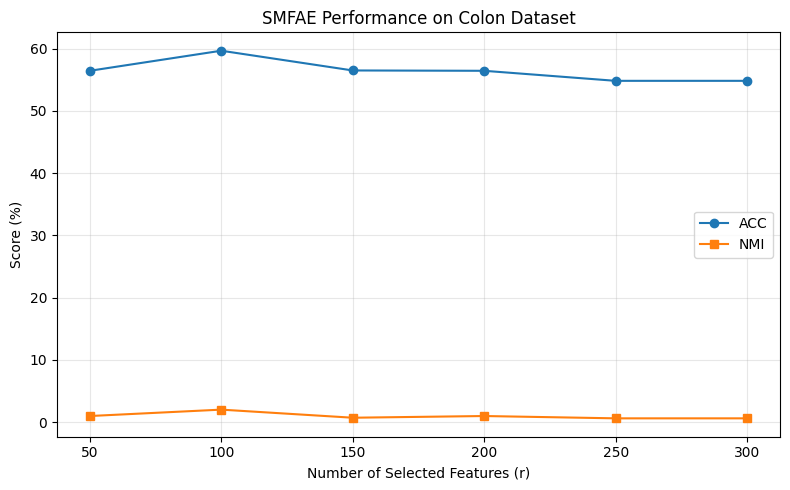

In [25]:
# ============================================================
# Final Colon Benchmark Visualization
# ============================================================

import matplotlib.pyplot as plt

plot_df = results_df.copy()

plt.figure(figsize=(8, 5))

plt.plot(
    plot_df["Selected Features (r)"],
    plot_df["ACC_mean"],
    marker="o",
    label="ACC"
)

plt.plot(
    plot_df["Selected Features (r)"],
    plot_df["NMI_mean"],
    marker="s",
    label="NMI"
)

plt.xlabel("Number of Selected Features (r)")
plt.ylabel("Score (%)")
plt.title("SMFAE Performance on Colon Dataset")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

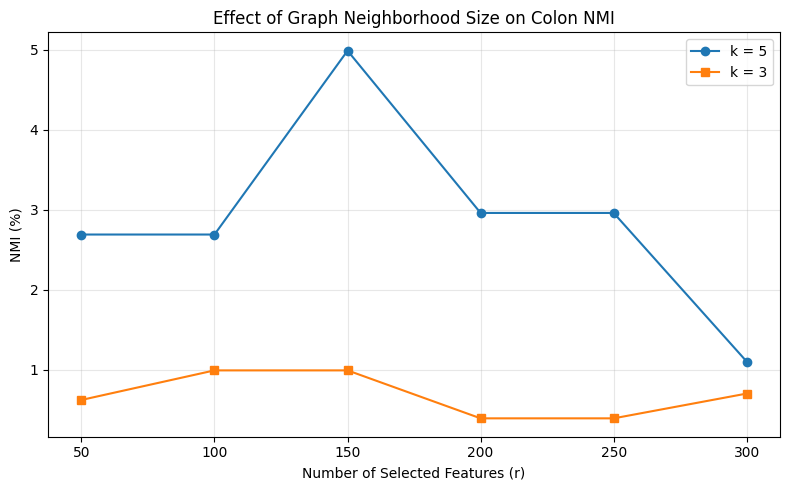

In [26]:
# ============================================================
# k=5 vs k=3 Comparison
# ============================================================

import matplotlib.pyplot as plt

feature_counts = [50, 100, 150, 200, 250, 300]

k5_nmi = [2.69, 2.69, 4.99, 2.96, 2.96, 1.10]
k3_nmi = [0.62, 0.99, 0.99, 0.39, 0.39, 0.70]

plt.figure(figsize=(8, 5))

plt.plot(
    feature_counts,
    k5_nmi,
    marker="o",
    label="k = 5"
)

plt.plot(
    feature_counts,
    k3_nmi,
    marker="s",
    label="k = 3"
)

plt.xlabel("Number of Selected Features (r)")
plt.ylabel("NMI (%)")
plt.title("Effect of Graph Neighborhood Size on Colon NMI")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [27]:
# ============================================================
# Save Colon Baseline Results
# ============================================================

import os
import pandas as pd

results_dir = "../reports/results"
results_file = os.path.join(
    results_dir,
    "accuracy_nmi.csv"
)

os.makedirs(results_dir, exist_ok=True)

columns = [
    "Method",
    "Dataset",
    "Num_Features",
    "ACC",
    "NMI",
    "Num_Samples",
    "Num_Original_Features",
    "Num_Classes",
    "Num_Selected_Features",
    "Hidden_Dimension",
    "Alpha",
    "Beta",
    "Gamma",
    "Omega",
    "ACC_Mean",
    "ACC_STD",
    "NMI_Mean",
    "NMI_STD"
]


# Create CSV only if it does not exist
if not os.path.exists(results_file):
    pd.DataFrame(columns=columns).to_csv(
        results_file,
        index=False
    )


# ------------------------------------------------------------
# Take values directly from results_df
# ------------------------------------------------------------

rows = []

for _, result in results_df.iterrows():

    rows.append({
        "Method": "Baseline",
        "Dataset": "Colon",

        "Num_Features": d_features,

        "ACC": result["ACC_mean"],
        "NMI": result["NMI_mean"],

        "Num_Samples": n_samples,
        "Num_Original_Features": d_features,
        "Num_Classes": n_classes,

        "Num_Selected_Features":
            result["Selected Features (r)"],

        "Hidden_Dimension": HIDDEN_DIM,

        "Alpha": alpha_val,
        "Beta": beta_val,
        "Gamma": gamma_val,
        "Omega": omega_val,

        "ACC_Mean": result["ACC_mean"],
        "ACC_STD": result["ACC_std"],

        "NMI_Mean": result["NMI_mean"],
        "NMI_STD": result["NMI_std"]
    })


# ------------------------------------------------------------
# Append to common CSV
# ------------------------------------------------------------

pd.DataFrame(
    rows,
    columns=columns
).to_csv(
    results_file,
    mode="a",
    header=False,
    index=False
)

print(f"Saved {len(rows)} Colon results.")
print(f"File: {results_file}")

Saved 6 Colon results.
File: ../reports/results\accuracy_nmi.csv


# SMFAE Existing-System Evaluation — Colon Microarray Dataset

## 1. Overview

This notebook presents the implementation, debugging, baseline evaluation, and controlled experimental analysis of the **Sparse Manifold Auto-Encoder (SMFAE)** method described in:

> Moslemi, A., & Jamshidi, M. (2025). *Unsupervised feature selection using sparse manifold learning: Auto-encoder approach*. Information Processing & Management, 62(1), 103923.

The experiments were conducted on the **Colon Microarray Dataset**.

### Dataset Characteristics

| Property | Value |
|---|---:|
| Number of samples | 62 |
| Number of features | 2000 |
| Number of classes | 2 |
| Input representation | \(X \in \mathbb{R}^{2000 \times 62}\) |
| Hidden dimension | 4 |
| Feature counts evaluated | 50, 100, 150, 200, 250, 300 |

The objective is to learn feature importance scores from the SMFAE encoder and evaluate the selected features using K-Means clustering.

---

## 2. Experimental Pipeline

The implementation consists of the following major stages:

1. Dataset loading and Z-score standardization.
2. Construction of the k-NN similarity graph and Graph Laplacian \(L_X\).
3. Computation of the operator scale \(C_{op}\).
4. SMFAE optimization using reconstruction, sparsity, weight-decay, and manifold terms.
5. Feature ranking using the row-wise \(L_2\)-norm of the encoder weight matrix.
6. Selection of the top \(r\) features.
7. Standardization of selected features before clustering.
8. K-Means clustering with repeated random initialization.
9. Evaluation using clustering Accuracy (ACC) and Normalized Mutual Information (NMI).

---

## 3. Initial Python Implementation

The initial implementation used:

- \(\alpha = 0.0001\)
- \(\beta = 0.0001\)
- \(\gamma = 50.0\)
- \(\omega = 0.01\)
- 250 training epochs

The initial best result was:

| Selected Features | ACC | NMI |
|---:|---:|---:|
| 100 | 56.45% | 0.99% |

### Initial Gradient Diagnostic

The encoder-gradient decomposition showed a strong dominance of the reconstruction term:

| Gradient Component | Norm | Relative Contribution |
|---|---:|---:|
| Reconstruction | 10.907188 | 99.62% |
| Sparsity | 0.447213 | 4.08% |
| Weight Decay | 0.000282 | 0.00% |
| Input Manifold | 0.059166 | 0.54% |
| Output Manifold | 0.000310 | 0.00% |
| Total Encoder | 10.948498 | — |

This indicated that the input-manifold contribution was strongly suppressed by the original \(C_{op}\) scaling.

---

## 4. Experiment 1 — Gradient Scaling and Hyperparameter Expansion

The input-manifold gradient was changed from a \(C_{op}\)-normalized form to:

\[
\gamma X L_X X^T W^{(1)}
\]

The hyperparameter search was also expanded over a logarithmic range of \(\gamma\).

The best configuration from this experiment was:

\[
\alpha=10^{-4},\quad
\beta=10^{-4},\quad
\gamma=0.001,\quad
\omega=0.01
\]

with 250 training epochs.

### Result

At \(r=100\):

- **ACC = 61.29%**
- **NMI = 2.22%**

The best mean NMI across the evaluated feature counts was **1.27%**.

The updated gradient diagnostic showed a substantially larger input-manifold contribution:

| Gradient Component | Norm | Relative Contribution |
|---|---:|---:|
| Reconstruction | 10.907188 | 85.66% |
| Sparsity | 0.447213 | 3.51% |
| Weight Decay | 0.000282 | 0.00% |
| Input Manifold | 3.668308 | 28.81% |
| Output Manifold | 0.000310 | 0.00% |
| Total Encoder | 12.733011 | — |
| Total Decoder | 8.672604 | — |

---

## 5. Experiment 2 — 500 Epochs, Gradient Clipping and Improved K-Means

To improve numerical stability and allow the auxiliary optimization variable \(H\) more time to update, the training configuration was changed to:

- Training epochs = **500**
- Gradient clipping = **[-10, 10]**
- K-Means `n_init = 50`
- 30 K-Means repetitions
- Selected-feature standardization retained

The resulting optimal configuration was:

\[
\boxed{
\alpha=10^{-4},\;
\beta=10^{-4},\;
\gamma=5\times10^{-4},\;
\omega=0.01
}
\]

### Best Colon Result

The strongest result obtained in the Python implementation was:

\[
\boxed{\text{ACC}=64.52\%,\quad \text{NMI}=4.99\%}
\]

using:

\[
\boxed{r=150}
\]

### Benchmark Results

| Selected Features \(r\) | ACC (%) | NMI (%) |
|---:|---:|---:|
| 50 | 61.29 ± 0.00 | 2.69 ± 0.00 |
| 100 | 61.29 ± 0.00 | 2.69 ± 0.00 |
| **150** | **64.52 ± 0.00** | **4.99 ± 0.00** |
| 200 | 62.90 ± 0.00 | 2.96 ± 0.00 |
| 250 | 62.90 ± 0.00 | 2.96 ± 0.00 |
| 300 | 58.06 ± 0.00 | 1.10 ± 0.00 |

The mean NMI across the six evaluated feature counts was **2.90%**.

This was the strongest configuration obtained during the Colon experiments.

---

## 6. Experiment 3 — Graph Neighborhood Size \(k=3\)

A final structural experiment was performed by changing the k-NN graph from:

\[
k=5 \rightarrow k=3
\]

while keeping the previously selected hyperparameters fixed:

- \(\alpha=0.0001\)
- \(\beta=0.0001\)
- \(\gamma=0.0005\)
- \(\omega=0.01\)
- Epochs = 500
- K-Means `n_init=50`

The graph operator scale changed from:

\[
C_{op}=55735.8727 \quad (k=5)
\]

to:

\[
C_{op}=34442.8355 \quad (k=3)
\]

### k=3 Results

| Selected Features \(r\) | ACC (%) | NMI (%) |
|---:|---:|---:|
| 50 | 54.84 ± 0.00 | 0.62 ± 0.00 |
| **100** | **56.45 ± 0.00** | **0.99 ± 0.00** |
| 150 | 56.45 ± 0.00 | 0.99 ± 0.00 |
| 200 | 54.84 ± 0.00 | 0.39 ± 0.00 |
| 250 | 54.84 ± 0.00 | 0.39 ± 0.00 |
| 300 | 56.45 ± 0.00 | 0.70 ± 0.00 |

Mean NMI across feature counts = **0.68%**.

### Conclusion

Reducing the graph neighborhood from \(k=5\) to \(k=3\) substantially degraded clustering performance. Therefore, **\(k=5\) is retained as the preferred graph setting for the Colon dataset**.

---

## 7. Overall Experimental Comparison

| Experiment | Best ACC | Best NMI | Configuration |
|---|---:|---:|---|
| Initial implementation | 56.45% | 0.99% | \(\gamma=50\), 250 epochs |
| Gradient scaling + expanded search | 61.29% | 2.22% | \(\gamma=0.001\), 250 epochs |
| 500 epochs + clipping + `n_init=50` | **64.52%** | **4.99%** | \(\gamma=0.0005\), 500 epochs |
| k=3 graph experiment | 56.45% | 0.99% | \(k=3\), fixed best hyperparameters |

### Best Overall Colon Configuration

\[
\boxed{
k=5,\;
\alpha=10^{-4},\;
\beta=10^{-4},\;
\gamma=5\times10^{-4},\;
\omega=0.01
}
\]

with:

- 500 training epochs
- Gradient clipping at ±10
- K-Means `n_init=50`
- 150 selected features

Best observed performance:

\[
ACC=64.52\%, NMI=4.99\%
\]

---

## 8. Interpretation and Limitations

The experiments demonstrate that the Python implementation can obtain substantially better clustering performance than the initial implementation through improved gradient balancing, longer optimization, numerical stabilization, and controlled hyperparameter selection.

However, the obtained NMI of **4.99%** remains substantially below the reported paper-level Colon result of approximately **29% NMI**. Therefore, the current implementation should be considered an **existing-system reproduction and experimental baseline**, rather than a successful exact reproduction of the reported paper performance.

The Colon dataset contains only 62 samples and 2000 features, making it a challenging high-dimensional, low-sample-size setting for unsupervised clustering. The k=3 experiment also showed that reducing the local graph neighborhood did not improve the representation for this dataset.

These observations motivate evaluating the implementation on an additional dataset with a larger number of samples and a different data structure.

---

## 9. Final Decision

The Colon experiments are considered complete.

### Frozen Colon Baseline

**Graph:**
- k-NN with \(k=5\)

**SMFAE:**
- \(\alpha=10^{-4}\)
- \(\beta=10^{-4}\)
- \(\gamma=5\times10^{-4}\)
- \(\omega=0.01\)

**Optimization:**
- 500 epochs
- Gradient clipping at ±10

**Feature Selection:**
- Feature importance based on encoder-weight \(L_2\)-norm
- Best observed \(r=150\)

**Clustering:**
- K-Means
- `n_init=50`
- 30 repetitions

**Final Colon Result:**

\[
ACC=64.52\%,NMI=4.99\%
\]

The implementation will now be carried forward to the next dataset using this Colon experiment as the completed existing-system baseline.